In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv('../data/raw/creditcard.csv')
print(df.shape)          # (284807, 31)
print(df.dtypes)
print(df.isnull().sum()) 

(284807, 31)
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.1727%


/var/folders/n_/g54j8x895rl59szwgfg17mf00000gn/T/ipykernel_66316/2768513251.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette=['#378ADD', '#E24B4A'])


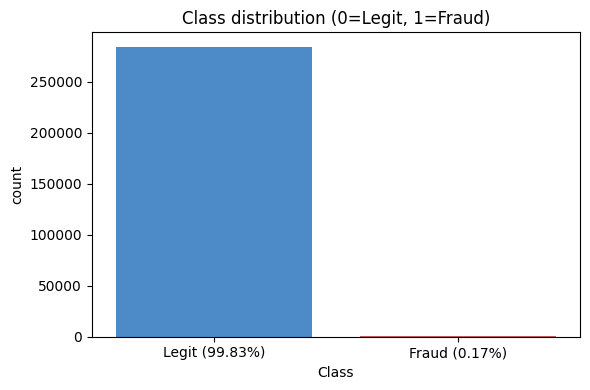

In [6]:
fraud_count = df['Class'].value_counts()
fraud_pct   = df['Class'].value_counts(normalize=True) * 100

print(fraud_count)
print(f"\nFraud rate: {fraud_pct[1]:.4f}%")  # ~0.17%

plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df, palette=['#378ADD', '#E24B4A'])
plt.title('Class distribution (0=Legit, 1=Fraud)')
plt.xticks([0, 1], ['Legit (99.83%)', 'Fraud (0.17%)'])
plt.tight_layout()
plt.savefig('../notebooks/figures/class_imbalance.png', dpi=150)

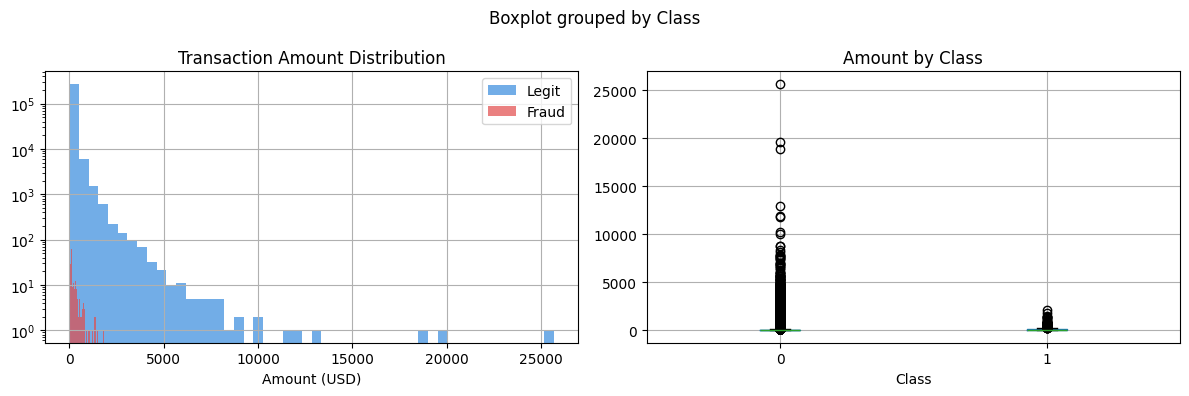

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Amount distribution by class
df[df['Class'] == 0]['Amount'].hist(bins=50, ax=axes[0], alpha=0.7, color='#378ADD', label='Legit')
df[df['Class'] == 1]['Amount'].hist(bins=50, ax=axes[0], alpha=0.7, color='#E24B4A', label='Fraud')
axes[0].set_title('Transaction Amount Distribution')
axes[0].set_xlabel('Amount (USD)')
axes[0].legend()
axes[0].set_yscale('log')  # log scale because of class imbalance

# Boxplot
df.boxplot(column='Amount', by='Class', ax=axes[1])
axes[1].set_title('Amount by Class')

plt.tight_layout()

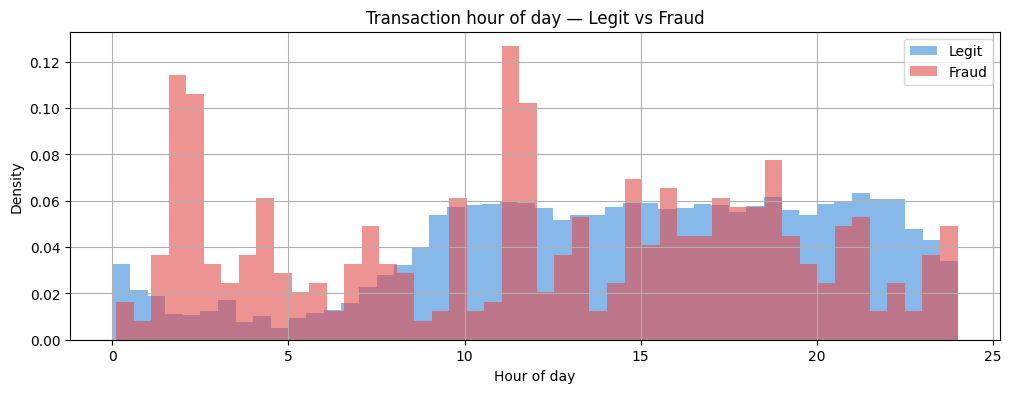

In [8]:
df['Hour'] = (df['Time'] % 86400) / 3600  # convert seconds → hour of day

plt.figure(figsize=(12, 4))
df[df['Class'] == 0]['Hour'].hist(bins=48, alpha=0.6, color='#378ADD', label='Legit', density=True)
df[df['Class'] == 1]['Hour'].hist(bins=48, alpha=0.6, color='#E24B4A', label='Fraud', density=True)
plt.title('Transaction hour of day — Legit vs Fraud')
plt.xlabel('Hour of day')
plt.ylabel('Density')
plt.legend()

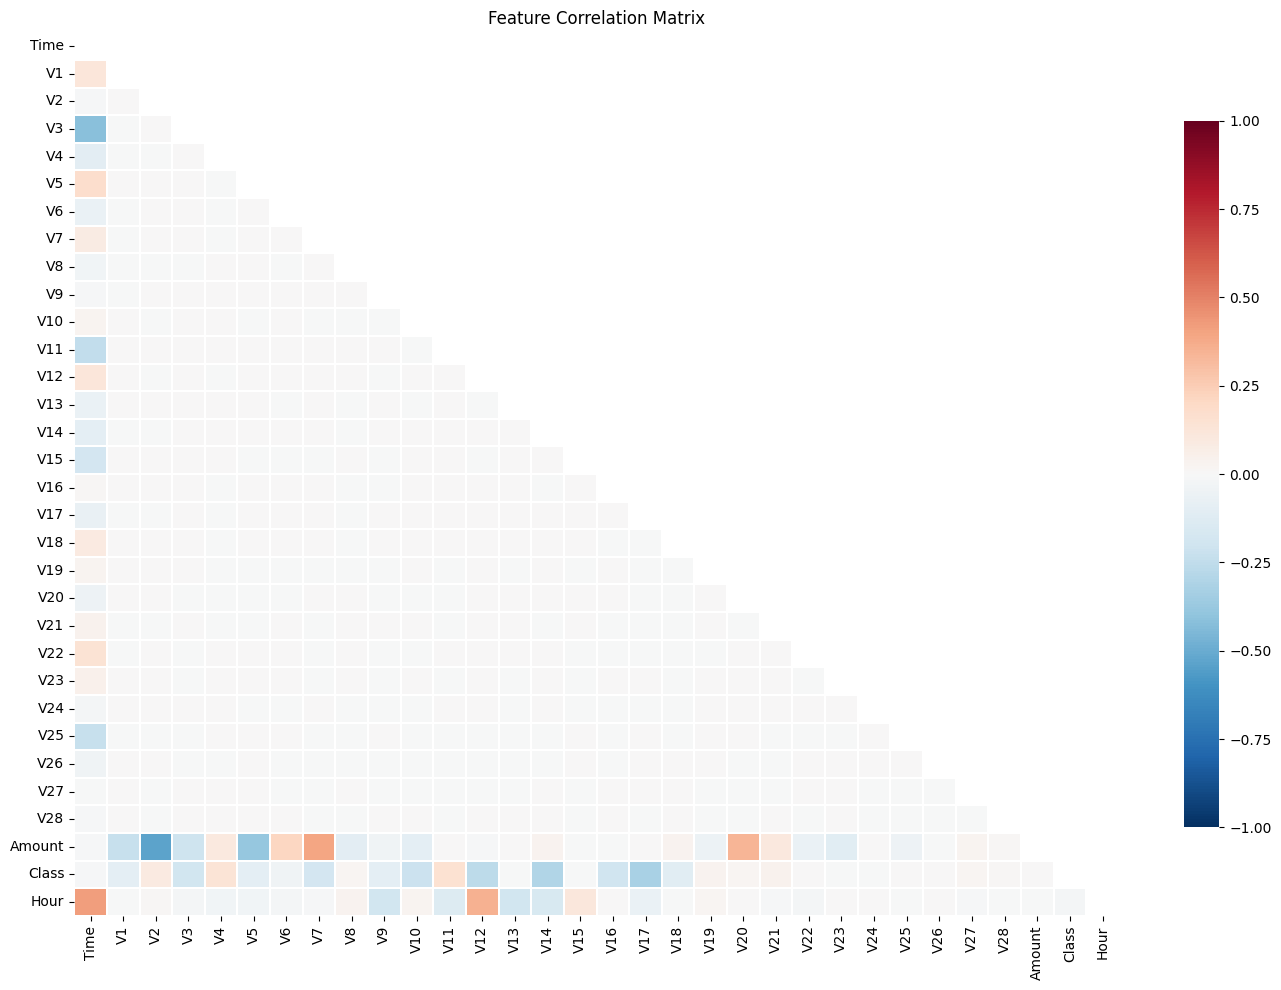

In [10]:
plt.figure(figsize=(14, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, linewidths=0.3,
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('../notebooks/figures/correlation_heatmap.png', dpi=150)

Top 10 features correlated with fraud:
V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485
Name: Class, dtype: float64


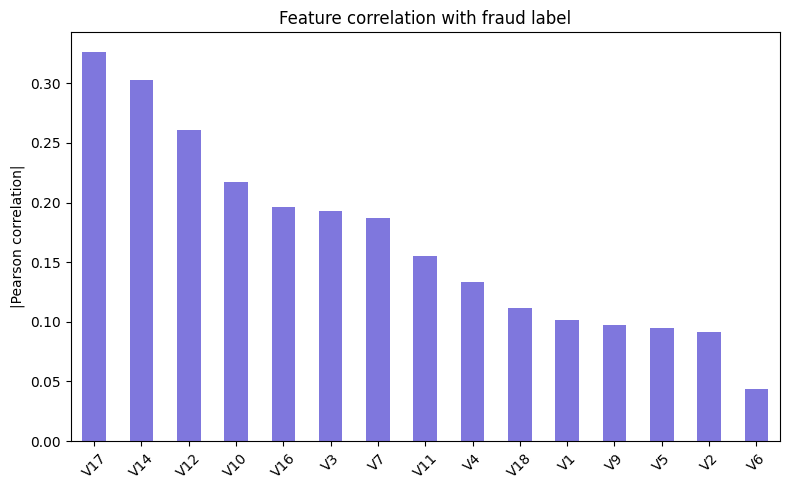

In [11]:
fraud_corr = df.corr()['Class'].drop('Class').abs().sort_values(ascending=False)
print("Top 10 features correlated with fraud:")
print(fraud_corr.head(10))

# Bar chart
plt.figure(figsize=(8, 5))
fraud_corr.head(15).plot(kind='bar', color='#7F77DD')
plt.title('Feature correlation with fraud label')
plt.ylabel('|Pearson correlation|')
plt.xticks(rotation=45)
plt.tight_layout()

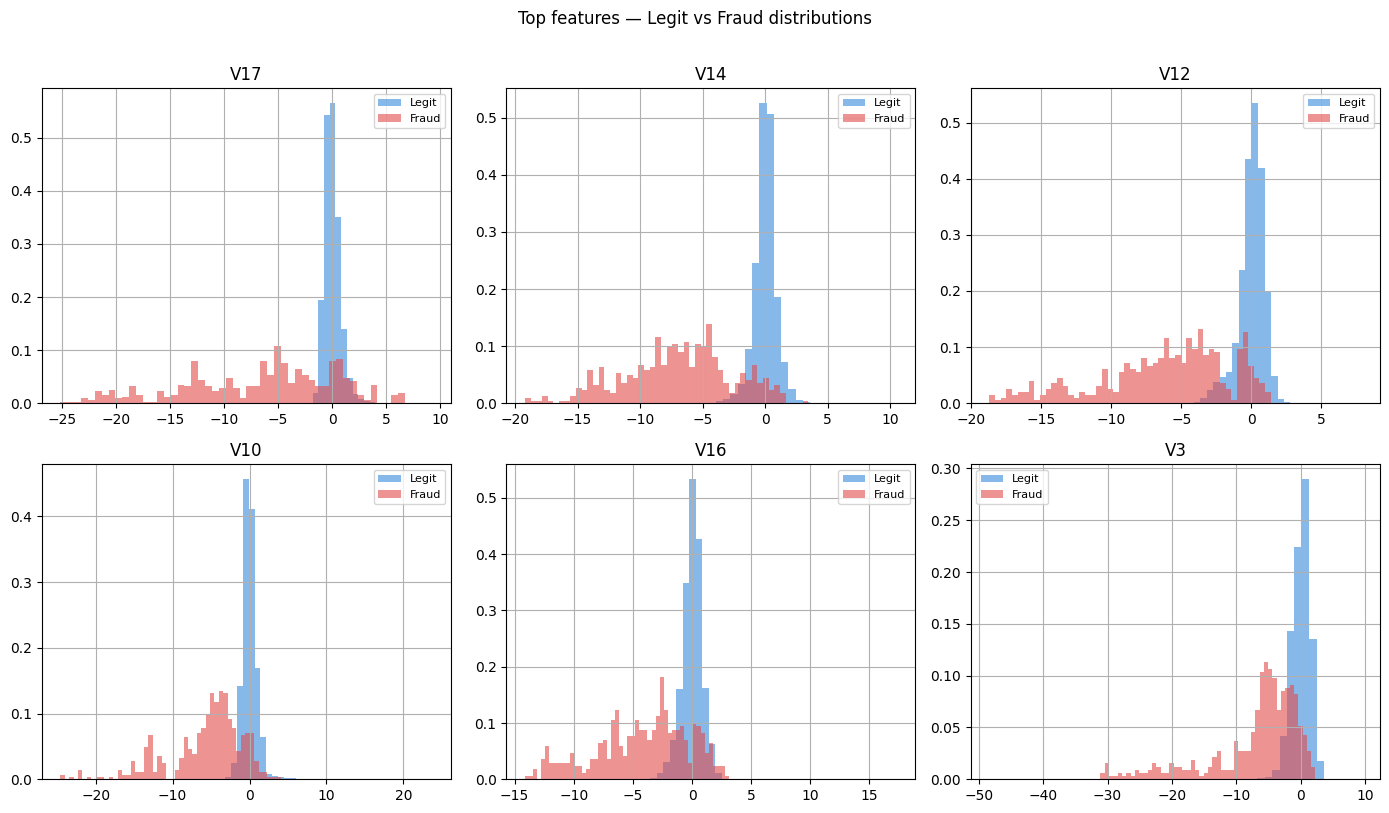

In [12]:
top_features = fraud_corr.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, feat in zip(axes.flatten(), top_features):
    df[df['Class']==0][feat].hist(bins=50, ax=ax, alpha=0.6, color='#378ADD', label='Legit', density=True)
    df[df['Class']==1][feat].hist(bins=50, ax=ax, alpha=0.6, color='#E24B4A', label='Fraud', density=True)
    ax.set_title(feat)
    ax.legend(fontsize=8)
plt.suptitle('Top features — Legit vs Fraud distributions', y=1.01)
plt.tight_layout()

In [13]:
print("=== DATASET SUMMARY ===")
print(f"Total transactions:  {len(df):,}")
print(f"Fraudulent:          {df['Class'].sum():,} ({df['Class'].mean()*100:.4f}%)")
print(f"Legitimate:          {(df['Class']==0).sum():,}")
print(f"\nAmount stats (fraud):")
print(df[df['Class']==1]['Amount'].describe())
print(f"\nAmount stats (legit):")
print(df[df['Class']==0]['Amount'].describe())

=== DATASET SUMMARY ===
Total transactions:  284,807
Fraudulent:          492 (0.1727%)
Legitimate:          284,315

Amount stats (fraud):
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

Amount stats (legit):
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64
